In [ ]:
# Connect to your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install the YOLOv8 engine
!pip install ultralytics -q

In [ ]:
# Copy the zip file from Drive to Colab's local storage
!cp "/content/drive/MyDrive/YOLO_Project/underwater_plastics.zip" "/content/"

print("✅ Copy complete. Unzipping data...")

# Unzip the file silently (-q) into a new folder called 'dataset'
!unzip -q /content/underwater_plastics.zip -d /content/dataset/

print("✅ Unzip complete! Data is ready for the GPU.")

✅ Copy complete. Unzipping data...
✅ Unzip complete! Data is ready for the GPU.


In [ ]:
import yaml
from ultralytics import YOLO

print("🚀 Configuring Cloud YAML Map...")

# 1. Build the perfect Cloud YAML configuration
cloud_yaml = {
    'train': '/content/dataset/underwater_plastics/train/images',
    'val': '/content/dataset/underwater_plastics/valid/images',
    'test': '/content/dataset/underwater_plastics/test/images',
    'nc': 15,
    'names': ['Mask', 'can', 'cellphone', 'electronics', 'gbottle', 'glove', 'metal', 'misc', 'net', 'pbag', 'pbottle', 'plastic', 'rod', 'sunglasses', 'tire']
}

# 2. Save it to Colab's storage
yaml_path = '/content/dataset/cloud_data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(cloud_yaml, f)

print(f"✅ YAML generated. Initializing T4 GPU Engine...")

# 3. Load the base model
model = YOLO('yolov8s.pt')

# 4. Launch Training
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    device=0,             # Target the Colab Nvidia GPU
    batch=16,
    name='deep_trash_cloud_v1'
)

print("\n✅ CLOUD TRAINING COMPLETE!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🚀 Configuring Cloud YAML Map...
✅ YAML generated. Initializing T4 GPU Engine...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/cloud_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscr

In [ ]:
import shutil

# Copy the trained weights back to your Google Drive project folder
source = '/content/runs/detect/deep_trash_cloud_v1/weights/best.pt'
destination = '/content/drive/MyDrive/YOLO_Project/deep_trash_best.pt'

shutil.copy(source, destination)
print("✅ SUCCESS: Model safely backed up to your Google Drive!")

✅ SUCCESS: Model safely backed up to your Google Drive!


In [ ]:
# Load your best weights
best_model = YOLO('/content/runs/detect/deep_trash_cloud_v1/weights/best.pt')

# Run a formal evaluation on the test split
metrics = best_model.val(split='test')

print(f"🏆 Final Test Accuracy (mAP50): {metrics.results_dict['metrics/mAP50(B)']:.4f}")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,131,389 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 10.3±4.3 MB/s, size: 50.9 KB)
val: Scanning /content/dataset/underwater_plastics/test/labels... 501 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 501/501 561.0it/s 0.9s
val: New cache created: /content/dataset/underwater_plastics/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 2.6it/s 12.3s
                   all        501        966       0.83      0.758      0.818      0.485
                  Mask         33         37          1      0.667      0.866      0.657
                   can         13         19      0.905      0.503       0.75      0.342
             cellphone         40         46      0.958      0.997      0.994      0.861
           electronics         14         19   

In [ ]:
# Replace 'underwater_plastics.zip' with your actual zip file name if it's different!
!unzip -q "/content/drive/MyDrive/YOLO_Project/underwater_plastics.zip" -d "/content/dataset/"

replace /content/dataset/__MACOSX/._underwater_plastics? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

🧠 Loading Master Debris Model...
🔍 Inspecting random image: uwg_g-741_jpg.rf.65818137e9ef54c0e740d05254945bf3.jpg

image 1/1 /content/dataset/underwater_plastics/test/images/uwg_g-741_jpg.rf.65818137e9ef54c0e740d05254945bf3.jpg: 640x640 1 pbag, 36.8ms
Speed: 2.3ms preprocess, 36.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


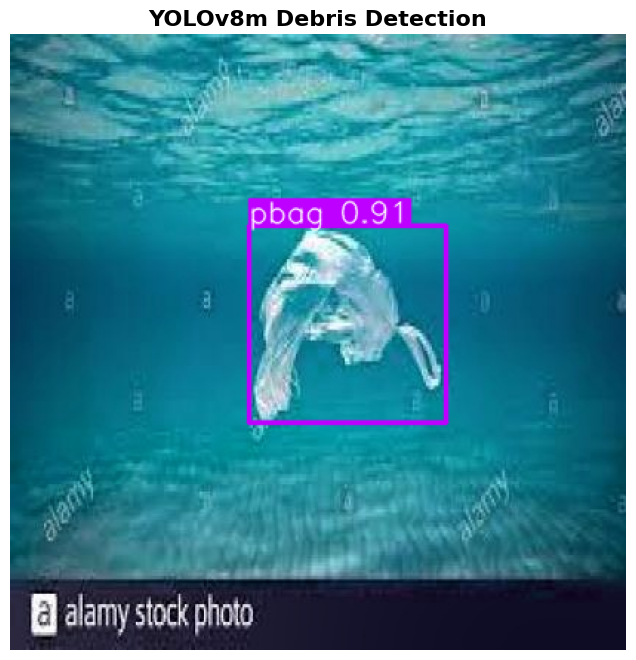

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os
import random

# 1. Load your newly saved 80% accurate brain
print("🧠 Loading Master Debris Model...")
model = YOLO('/content/drive/MyDrive/YOLO_Project/debris_v2_medium_best.pt')

# 2. Pick a random image from your testing dataset
# (Ensure this path matches where your unzipped data is)
test_dir = '/content/dataset/underwater_plastics/test/images'

if not os.path.exists(test_dir):
    print(f"❌ Cannot find test images at {test_dir}. Update the path!")
else:
    all_test_images = [f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    random_image = random.choice(all_test_images)
    img_path = os.path.join(test_dir, random_image)

    print(f"🔍 Inspecting random image: {random_image}")

    # 3. Run Inference (The AI prediction)
    # conf=0.4 means "only show me boxes you are 40% or more confident in"
    results = model(img_path, conf=0.4)

    # 4. Extract the plotted image and display it
    res_plotted = results[0].plot()
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB) # Convert colors for matplotlib

    plt.figure(figsize=(12, 8))
    plt.imshow(res_rgb)
    plt.axis('off')
    plt.title(f"YOLOv8m Debris Detection", fontsize=16, fontweight='bold')
    plt.show()

In [ ]:
!unzip -q "/content/drive/MyDrive/YOLO_Project/underwater_plastics.zip" -d "/content/dataset/"
print("✅ Dataset restored to Colab memory!")

replace /content/dataset/__MACOSX/._underwater_plastics? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import os

print("🧠 Loading Master Debris Model from Drive Vault...")
model = YOLO('/content/drive/MyDrive/YOLO_Project/debris_v2_medium_best.pt')

# Point it to the dataset we just unzipped
yaml_path = '/content/dataset/underwater_plastics/data.yaml'

print("\n🔄 Running validation. YOLO is grading itself and drawing charts (~60 seconds)...")
metrics = model.val(data=yaml_path, plots=True)

# Grab the new folder where YOLO saved the charts
run_dir = metrics.save_dir
print(f"\n✅ Charts successfully regenerated at: {run_dir}\n")

# The charts you need for your presentation
charts_to_show = [
    ('confusion_matrix_normalized.png', '🔀 Confusion Matrix (Normalized)'),
    ('F1_curve.png', '⚖️ F1 Score Curve'),
    ('val_batch0_pred.jpg', '🎯 Validation Predictions')
]

for filename, title in charts_to_show:
    filepath = os.path.join(run_dir, filename)
    if os.path.exists(filepath):
        plt.figure(figsize=(15, 10))
        img = Image.open(filepath)
        plt.imshow(img)
        plt.axis('off')
        plt.title(title, fontsize=18, fontweight='bold', pad=20)
        plt.show()
    else:
        print(f"⚠️ Could not find {filename}")